## HEALPix — plotting methods

HEALPix (Hierarchical Equal Area isoLatitude Pixelisation) divides the sphere
into equal-area pixels arranged in rings of constant latitude.  It is used as
the native output grid of the ECMWF AIFS machine-learning forecast model.

Because HEALPix data is stored as a 1-D array of unordered pixel values,
different plotting methods make different trade-offs between accuracy and speed:

| Method | How it works | Best for |
|---|---|---|
| `grid_cells` | Draws each pixel as its true diamond-shaped polygon | Seeing exact cell geometry |
| `point_cloud` | Plots a coloured marker at each pixel centre | Quick inspection, sparse data |
| `contourf` | Interpolates to a regular grid then draws filled contours | Smooth, publication-quality maps |

This notebook loads a HEALPix H128 2-metre temperature field and shows all
three methods side-by-side.

In [1]:
import earthkit.data as ekd

import earthkit.plots as ekp

data = ekd.from_source("sample", "healpix-h128-nested-2t.grib")

healpix-h128-nested-2t.grib:   0%|          | 0.00/385k [00:00<?, ?B/s]

### Shared style

We define a single `Style` object and reuse it across all subplots so the
colour scale is identical in every panel.

In [2]:
style = ekp.styles.Style(levels=range(0, 21), colors="Spectral_r", units="celsius")

### All methods side-by-side

Each subplot uses the same domain (France and Spain) so the different cell
geometries and interpolation effects are easy to compare.

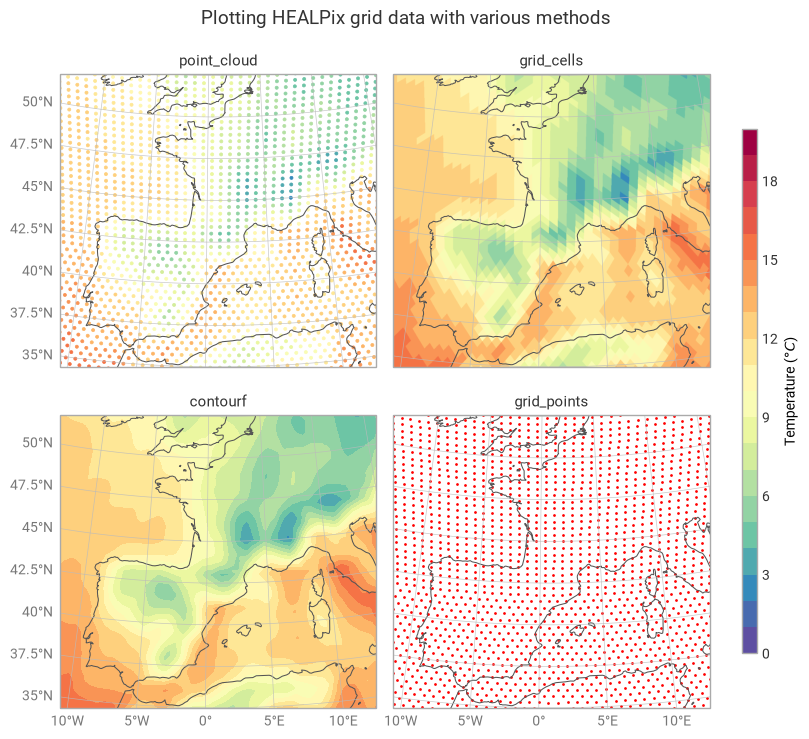

In [3]:
figure = ekp.Figure(rows=2, columns=2, domain=["France", "Spain"])

for method in ["point_cloud", "grid_cells", "contourf", "grid_points"]:
    subplot = figure.add_map()
    getattr(subplot, method)(data, style=style)
    subplot.title(method)

figure.coastlines()
figure.gridlines()

figure.title("Plotting HEALPix grid data with various methods")

figure.legend(location="right")

figure.show()

### What to notice

- **`grid_cells`** shows the true HEALPix pixel boundaries — the distinctive
  diamond shapes that give HEALPix its equal-area property.
- **`point_cloud`** places one dot per pixel centre.  At this resolution
  (H128 ≈ 0.46°) the dots are close enough to fill in, but zooming out would
  reveal gaps.
- **`contourf`** interpolates to a regular grid before contouring, producing a
  smooth result at the cost of some spatial accuracy near sharp gradients.